# 📋 Notebook 2 — Baseline Replication: Saeed (2025)

**Reference:**
> Saeed, E.M.H. (2025). *An Ensemble Voting Classifier based on Machine Learning Models for Phishing Detection.* IJSRSET, 12(1), 15–27. DOI: 10.32628/IJSRSET251211

## What the paper reports (per model):
1. **Confusion Matrix** — heatmap with raw TP/TN/FP/FN counts
2. **Classification Report** — precision, recall, f1-score, support for each class + accuracy + macro avg + weighted avg
3. **Table I** — accuracy comparison across all models

## Exact methodology reproduced:
- Dataset: UCI Phishing Websites (`phishing-2020.csv`), labels: 1=phishing, -1=legitimate
- Preprocessing: `StandardScaler` only — **no deduplication, no SMOTE**
- Split: **80% train / 20% test**, `random_state=42`, **no stratify**
  - Verified: reproduces paper's exact test set (class 0: 976, class 1: 1235, total: 2211)
- Models: Logistic Regression, Gradient Boosting, K-Nearest Neighbors (all sklearn defaults)
- Ensemble: Hard Voting (majority class label)
- No cross-validation, no hyperparameter tuning

## Datasets run:
- **DS-Baseline raw** — exact Saeed (2025) conditions (no dedup)
- **DS-Baseline deduped** — our honest re-run (quantifies inflation)
- **DS01 LegitPhish 2025** — new dataset; no prior baseline exists

In [1]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})
SEED = 42
print('✅ Setup complete.')

✅ Setup complete.


In [2]:
# ==========================================
# 2. LOAD DATASETS
# ==========================================

# --- DS-Baseline (UCI Phishing Websites) ---
# Original labels: 1=phishing, -1=legitimate
df_base_raw = pd.read_csv('phishing-2020.csv')
df_base_raw = df_base_raw.drop(columns=['Index'], errors='ignore')
df_base_raw['label'] = df_base_raw['class'].map({1: 1, -1: 0})
df_base_raw = df_base_raw.drop(columns=['class'])
# Sanity checks
assert df_base_raw['label'].isnull().sum() == 0, 'Unexpected nulls in DS-Baseline label'
assert df_base_raw.isnull().sum().sum() == 0, 'Unexpected nulls in DS-Baseline features'

# --- DS01 (LegitPhish 2025) ---
# Original labels: 0=phishing, 1=legitimate
df_ds01_raw = pd.read_csv('LegitPhish2025.csv')
df_ds01_raw['label'] = df_ds01_raw['ClassLabel'].map({0: 1, 1: 0})
df_ds01_raw = df_ds01_raw.drop(columns=['ClassLabel', 'URL'], errors='ignore')
# Convert any remaining object columns to numeric
for col in df_ds01_raw.columns:
    if col != 'label' and df_ds01_raw[col].dtype == 'object':
        df_ds01_raw[col] = pd.to_numeric(df_ds01_raw[col], errors='coerce')
df_ds01_raw = df_ds01_raw.fillna(0)
assert df_ds01_raw['label'].isnull().sum() == 0, 'Unexpected nulls in DS01 label'

print('DS-Baseline (raw):')
print(f'  Rows: {len(df_base_raw):,}  |  Duplicates: {df_base_raw.duplicated().sum():,}'
      f'  ({df_base_raw.duplicated().sum()/len(df_base_raw)*100:.1f}%)')
print(f'  Class 0 (legitimate): {(df_base_raw.label==0).sum():,}  |  '
      f'Class 1 (phishing): {(df_base_raw.label==1).sum():,}')
print()
print('DS01 (LegitPhish 2025, raw):')
print(f'  Rows: {len(df_ds01_raw):,}  |  Duplicates: {df_ds01_raw.duplicated().sum():,}'
      f'  ({df_ds01_raw.duplicated().sum()/len(df_ds01_raw)*100:.1f}%)')
print(f'  Class 0 (legitimate): {(df_ds01_raw.label==0).sum():,}  |  '
      f'Class 1 (phishing): {(df_ds01_raw.label==1).sum():,}')

DS-Baseline (raw):
  Rows: 11,054  |  Duplicates: 5,205  (47.1%)
  Class 0 (legitimate): 4,897  |  Class 1 (phishing): 6,157

DS01 (LegitPhish 2025, raw):
  Rows: 101,219  |  Duplicates: 69,411  (68.6%)
  Class 0 (legitimate): 37,541  |  Class 1 (phishing): 63,678


In [3]:
# ==========================================
# 3. UTILITY FUNCTIONS
# ==========================================

def plot_confusion_matrix(y_true, y_pred, model_name, dataset_label, ax):
    """
    Plots a confusion matrix styled exactly as in Saeed (2025):
    - Raw counts annotated
    - True Labels on y-axis, Predicted Labels on x-axis
    - Class values 0 (legitimate) and 1 (phishing)
    """
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=[0, 1], yticklabels=[0, 1],
        linewidths=0.5, linecolor='white', cbar=True,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_xlabel('Predicted Labels', fontsize=11)
    ax.set_ylabel('True Labels', fontsize=11)
    ax.set_title(f'Confusion Matrix\n{model_name}\n({dataset_label})', fontweight='bold')


def print_classification_report(y_true, y_pred, model_name, dataset_label):
    """Prints sklearn classification report exactly as paper shows it."""
    print(f'\n--- {model_name} | {dataset_label} ---')
    print(classification_report(
        y_true, y_pred,
        target_names=['0 (legitimate)', '1 (phishing)'],
        digits=2
    ))


def get_metrics(y_true, y_pred, model_name):
    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
    }


print('✅ Utilities ready.')

✅ Utilities ready.


In [4]:
# ==========================================
# 4. SAEED (2025) PIPELINE FUNCTION
# ==========================================

def run_saeed_pipeline(df, dataset_label, dedup=False):
    """
    Faithful replication of Saeed (2025) pipeline.
    dedup=False : raw data, matches their exact conditions
    dedup=True  : deduplicated, honest evaluation
    """
    condition = 'raw — matches Saeed (2025)' if not dedup else 'deduped — honest'
    print(f'\n{"="*60}')
    print(f'  {dataset_label} [{condition}]')
    print(f'{"="*60}')

    data = df.drop_duplicates().reset_index(drop=True) if dedup else df.copy()

    X = data.drop(columns=['label'])
    y = data['label']
    print(f'  Rows: {len(data):,}  |  '
          f'Legitimate (0): {(y==0).sum():,}  |  '
          f'Phishing (1): {(y==1).sum():,}')

    # Exact Saeed split: 80/20, no stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )
    print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')
    print(f'  Test class 0: {(y_test==0).sum():,}  |  Test class 1: {(y_test==1).sum():,}')

    # StandardScaler (their only preprocessing step)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Individual models — sklearn defaults as per paper
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
        'Gradient Boosting':   GradientBoostingClassifier(random_state=SEED),
        'KNN':                 KNeighborsClassifier(),  # default n_neighbors=5
    }

    results   = []
    all_preds = {}

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
        all_preds[name] = pred
        results.append(get_metrics(y_test, pred, name))

    # Hard Voting Ensemble
    ensemble = VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(max_iter=1000, random_state=SEED)),
            ('gb',  GradientBoostingClassifier(random_state=SEED)),
            ('knn', KNeighborsClassifier()),
        ],
        voting='hard'
    )
    ensemble.fit(X_train_s, y_train)
    ens_pred = ensemble.predict(X_test_s)
    all_preds['Hard Voting Ensemble'] = ens_pred
    results.append(get_metrics(y_test, ens_pred, 'Hard Voting Ensemble'))

    df_results = pd.DataFrame(results)
    df_results['Dataset'] = dataset_label
    df_results['Deduped'] = dedup

    return df_results, all_preds, y_test


print('✅ Pipeline function ready.')

✅ Pipeline function ready.


In [5]:
# ==========================================
# 5. RUN — DS-BASELINE RAW (replicates paper)
# ==========================================

res_raw, preds_raw, yt_raw = run_saeed_pipeline(
    df_base_raw, 'DS-Baseline', dedup=False
)


  DS-Baseline [raw — matches Saeed (2025)]
  Rows: 11,054  |  Legitimate (0): 4,897  |  Phishing (1): 6,157
  Train: 8,843  |  Test: 2,211
  Test class 0: 976  |  Test class 1: 1,235


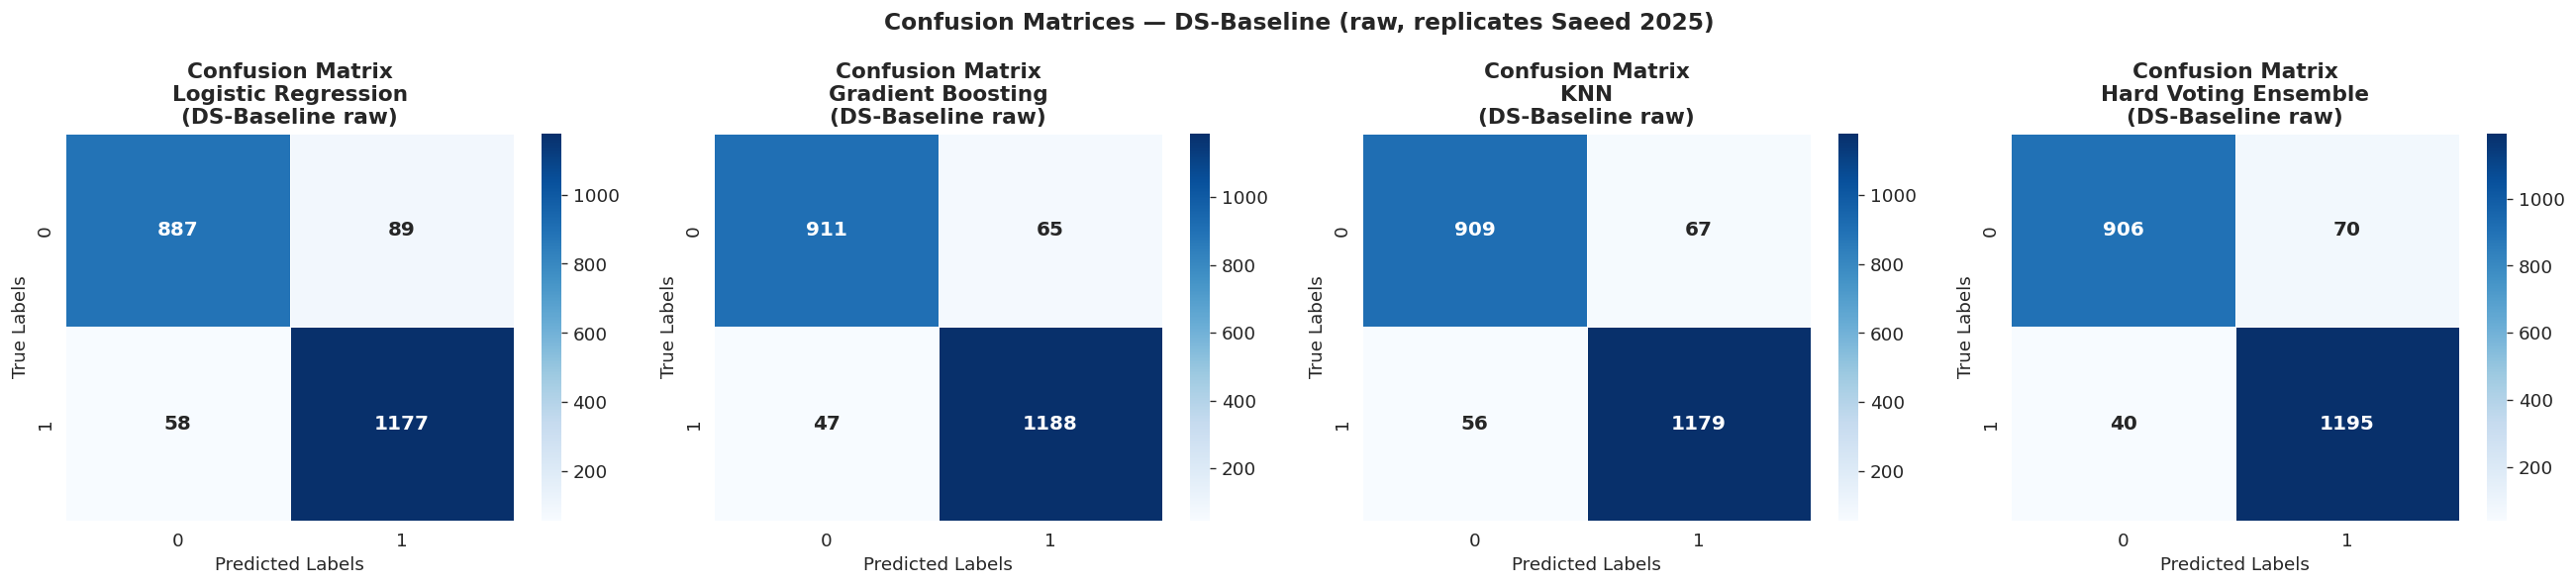

Saved: nb2_cm_baseline_raw.png


In [6]:
# ── Confusion Matrices — DS-Baseline raw ──

model_order = ['Logistic Regression', 'Gradient Boosting', 'KNN', 'Hard Voting Ensemble']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, model_order):
    plot_confusion_matrix(yt_raw, preds_raw[name], name, 'DS-Baseline raw', ax)

fig.suptitle('Confusion Matrices — DS-Baseline (raw, replicates Saeed 2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb2_cm_baseline_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_cm_baseline_raw.png')

In [7]:
# ── Classification Reports — DS-Baseline raw ──

for name in model_order:
    print_classification_report(yt_raw, preds_raw[name], name, 'DS-Baseline raw')


--- Logistic Regression | DS-Baseline raw ---
                precision    recall  f1-score   support

0 (legitimate)       0.94      0.91      0.92       976
  1 (phishing)       0.93      0.95      0.94      1235

      accuracy                           0.93      2211
     macro avg       0.93      0.93      0.93      2211
  weighted avg       0.93      0.93      0.93      2211


--- Gradient Boosting | DS-Baseline raw ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.93      0.94       976
  1 (phishing)       0.95      0.96      0.95      1235

      accuracy                           0.95      2211
     macro avg       0.95      0.95      0.95      2211
  weighted avg       0.95      0.95      0.95      2211


--- KNN | DS-Baseline raw ---
                precision    recall  f1-score   support

0 (legitimate)       0.94      0.93      0.94       976
  1 (phishing)       0.95      0.95      0.95      1235

      accuracy               

In [8]:
# ── Accuracy Table — DS-Baseline raw (mirrors Table I of paper) ──

published = {
    'Logistic Regression':  93.31,
    'Gradient Boosting':    94.93,
    'KNN':                  94.35,
    'Hard Voting Ensemble': 95.02,
}

print('\nTable I (replicated) — DS-Baseline raw:')
print(f'{"Model":<26} {"Replicated":>12} {"Published":>12} {"Match?":>8}')
print('-' * 62)
for _, row in res_raw.iterrows():
    pub = published.get(row['Model'], None)
    match = '✅' if pub and abs(row['Accuracy'] - pub) < 1.0 else '⚠️'
    pub_s = f'{pub:.2f}%' if pub else 'N/A'
    print(f'{row["Model"]:<26} {row["Accuracy"]:>10.2f}%  {pub_s:>10}  {match}')


Table I (replicated) — DS-Baseline raw:
Model                        Replicated    Published   Match?
--------------------------------------------------------------
Logistic Regression             93.35%      93.31%  ✅
Gradient Boosting               94.93%      94.93%  ✅
KNN                             94.44%      94.35%  ✅
Hard Voting Ensemble            95.02%      95.02%  ✅


In [9]:
# ==========================================
# 6. RUN — DS-BASELINE DEDUPED (honest)
# ==========================================

res_dedup, preds_dedup, yt_dedup = run_saeed_pipeline(
    df_base_raw, 'DS-Baseline', dedup=True
)


  DS-Baseline [deduped — honest]
  Rows: 5,849  |  Legitimate (0): 3,019  |  Phishing (1): 2,830
  Train: 4,679  |  Test: 1,170
  Test class 0: 631  |  Test class 1: 539


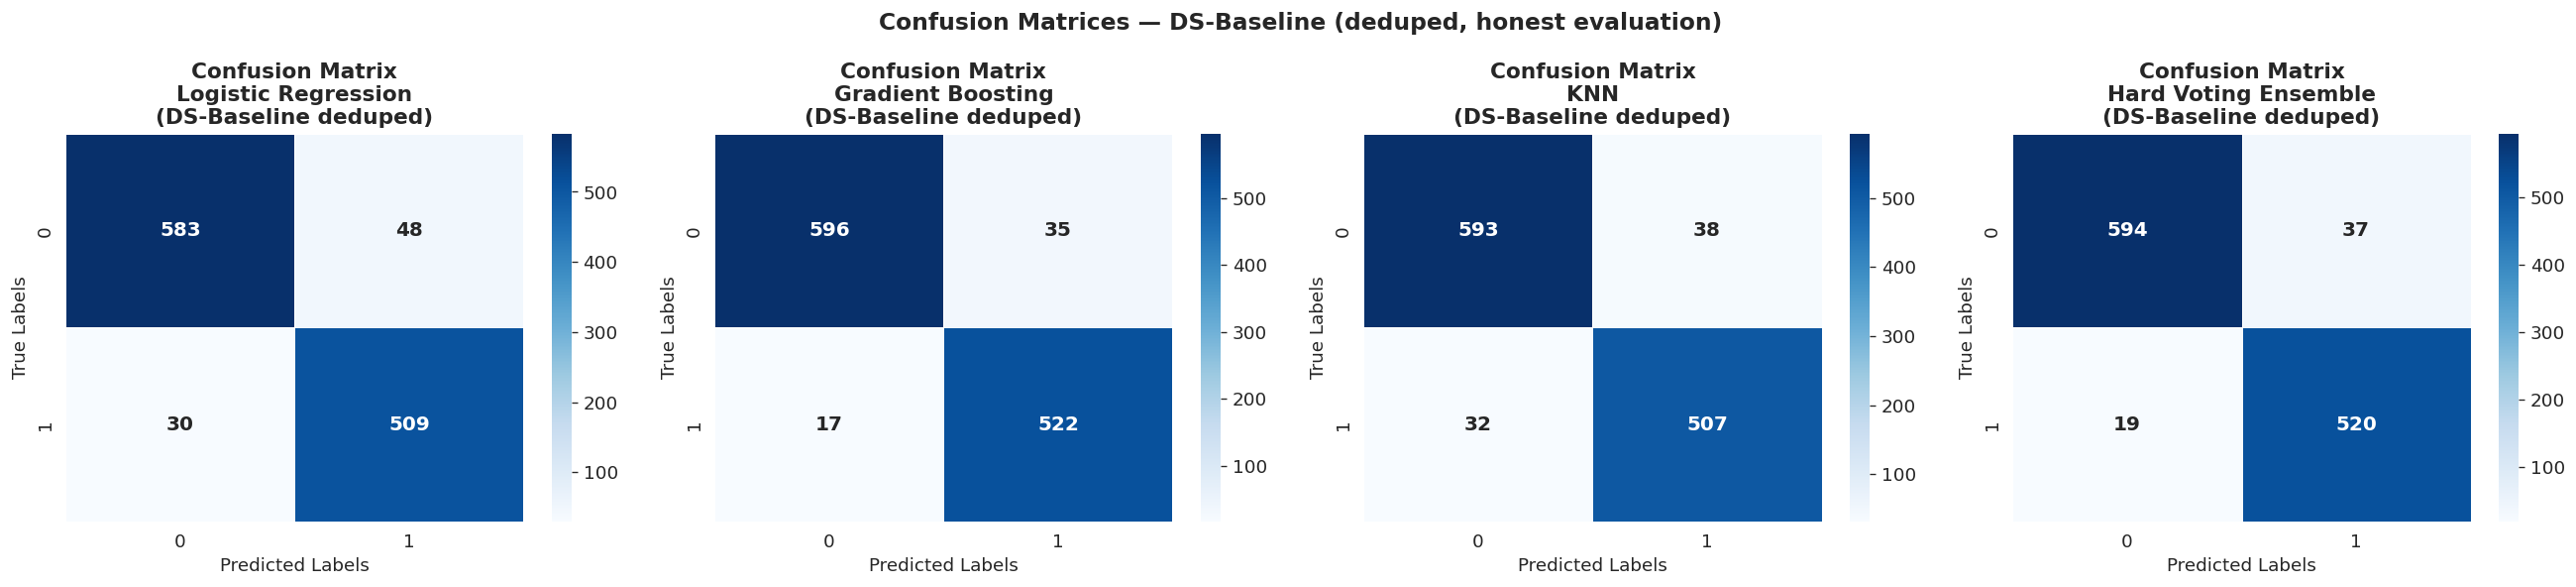

Saved: nb2_cm_baseline_deduped.png


In [10]:
# ── Confusion Matrices — DS-Baseline deduped ──

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, model_order):
    plot_confusion_matrix(yt_dedup, preds_dedup[name], name, 'DS-Baseline deduped', ax)

fig.suptitle('Confusion Matrices — DS-Baseline (deduped, honest evaluation)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb2_cm_baseline_deduped.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_cm_baseline_deduped.png')

In [11]:
# ── Classification Reports — DS-Baseline deduped ──

for name in model_order:
    print_classification_report(yt_dedup, preds_dedup[name], name, 'DS-Baseline deduped')


--- Logistic Regression | DS-Baseline deduped ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.92      0.94       631
  1 (phishing)       0.91      0.94      0.93       539

      accuracy                           0.93      1170
     macro avg       0.93      0.93      0.93      1170
  weighted avg       0.93      0.93      0.93      1170


--- Gradient Boosting | DS-Baseline deduped ---
                precision    recall  f1-score   support

0 (legitimate)       0.97      0.94      0.96       631
  1 (phishing)       0.94      0.97      0.95       539

      accuracy                           0.96      1170
     macro avg       0.95      0.96      0.96      1170
  weighted avg       0.96      0.96      0.96      1170


--- KNN | DS-Baseline deduped ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.94      0.94       631
  1 (phishing)       0.93      0.94      0.94       539

      accuracy   

In [12]:
# ==========================================
# 7. RUN — DS01 LEGITPHISH 2025
# ==========================================
# DS01 is always used deduped (our standard practice).
# This gives the first-ever result of the Saeed pipeline on this dataset.

res_ds01, preds_ds01, yt_ds01 = run_saeed_pipeline(
    df_ds01_raw, 'DS01 LegitPhish 2025', dedup=True
)


  DS01 LegitPhish 2025 [deduped — honest]
  Rows: 31,808  |  Legitimate (0): 7,059  |  Phishing (1): 24,749
  Train: 25,446  |  Test: 6,362
  Test class 0: 1,404  |  Test class 1: 4,958


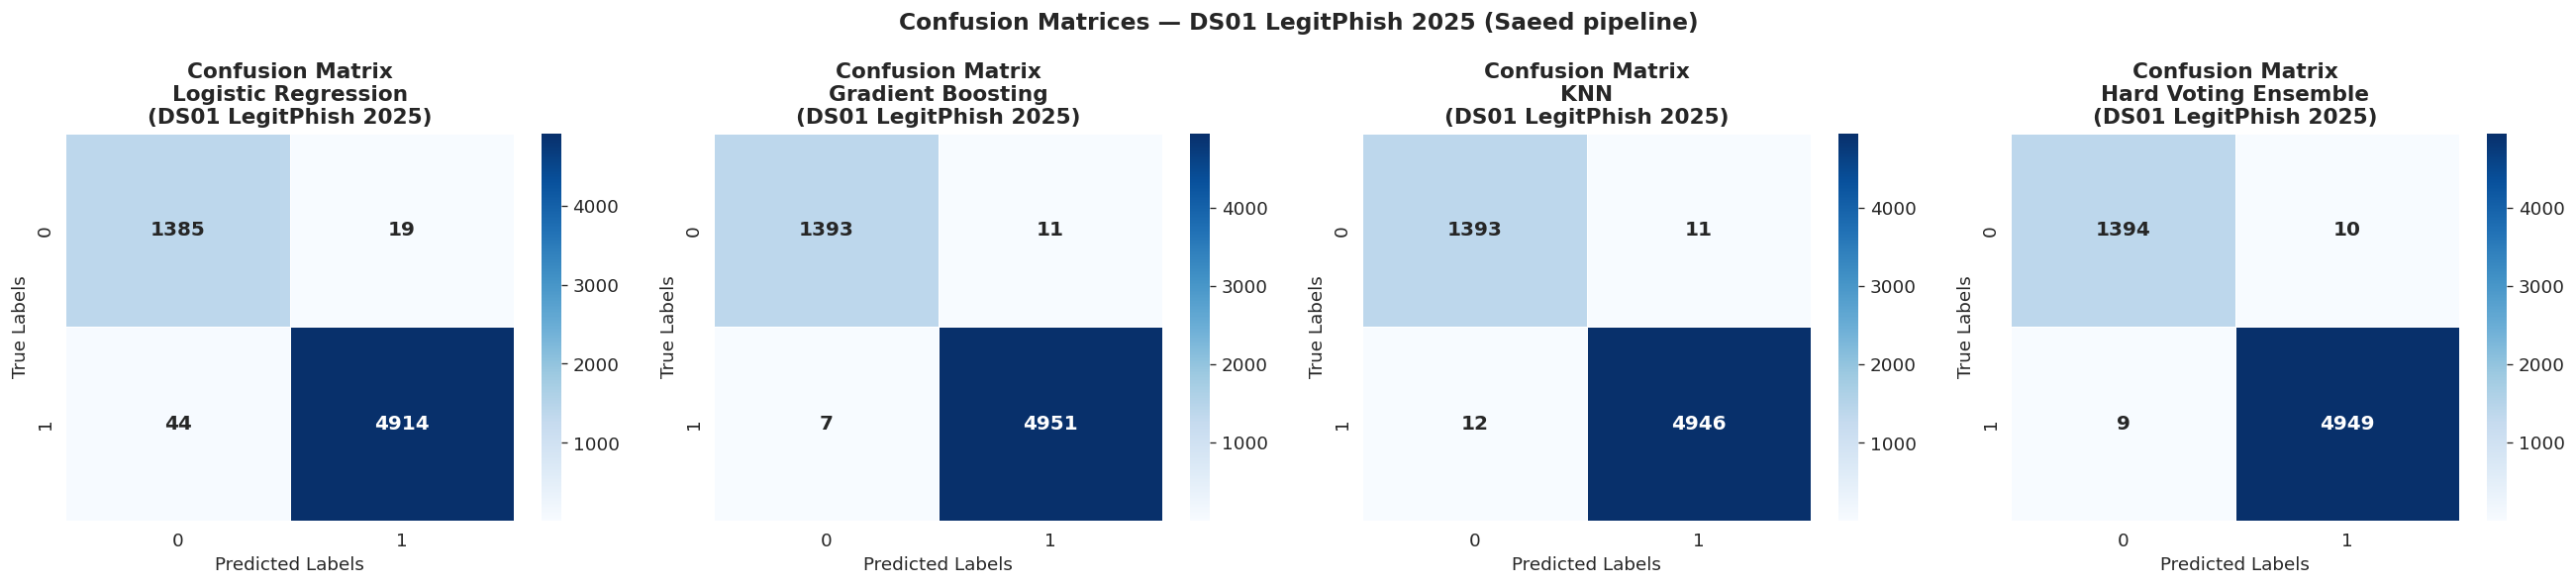

Saved: nb2_cm_ds01.png


In [13]:
# ── Confusion Matrices — DS01 ──

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, model_order):
    plot_confusion_matrix(yt_ds01, preds_ds01[name], name, 'DS01 LegitPhish 2025', ax)

fig.suptitle('Confusion Matrices — DS01 LegitPhish 2025 (Saeed pipeline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb2_cm_ds01.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_cm_ds01.png')

In [14]:
# ── Classification Reports — DS01 ──

for name in model_order:
    print_classification_report(yt_ds01, preds_ds01[name], name, 'DS01 LegitPhish 2025')


--- Logistic Regression | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       0.97      0.99      0.98      1404
  1 (phishing)       1.00      0.99      0.99      4958

      accuracy                           0.99      6362
     macro avg       0.98      0.99      0.99      6362
  weighted avg       0.99      0.99      0.99      6362


--- Gradient Boosting | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       0.99      0.99      0.99      1404
  1 (phishing)       1.00      1.00      1.00      4958

      accuracy                           1.00      6362
     macro avg       1.00      1.00      1.00      6362
  weighted avg       1.00      1.00      1.00      6362


--- KNN | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       0.99      0.99      0.99      1404
  1 (phishing)       1.00      1.00      1.00      4958

      accuracy

In [15]:
# ==========================================
# 8. FULL RESULTS TABLE (all conditions)
# ==========================================

df_all = pd.concat([res_raw, res_dedup, res_ds01], ignore_index=True)

print('\n📌 SAEED (2025) REPLICATION — COMPLETE RESULTS')
print('='*72)

for (ds, dedup), grp in df_all.groupby(['Dataset','Deduped']):
    cond = 'deduped' if dedup else 'raw'
    print(f'\n🔹 {ds} [{cond}]')
    print(f'  {"Model":<26} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
    print('  ' + '-'*65)
    for _, row in grp.iterrows():
        print(f'  {row["Model"]:<26} {row["Accuracy"]:>9.2f}%'
              f' {row["Precision"]:>10.2f}%'
              f' {row["Recall"]:>8.2f}%'
              f' {row["F1"]:>8.2f}%')

print()
print('NOTE: DS-Baseline raw replicates Saeed (2025) published results.')
print('      DS-Baseline deduped shows honest accuracy after removing duplicate rows.')
print('      DS01 provides the first baseline result for this dataset.')


📌 SAEED (2025) REPLICATION — COMPLETE RESULTS

🔹 DS-Baseline [raw]
  Model                        Accuracy   Precision    Recall        F1
  -----------------------------------------------------------------
  Logistic Regression            93.35%      92.97%    95.30%    94.12%
  Gradient Boosting              94.93%      94.81%    96.19%    95.50%
  KNN                            94.44%      94.62%    95.47%    95.04%
  Hard Voting Ensemble           95.02%      94.47%    96.76%    95.60%

🔹 DS-Baseline [deduped]
  Model                        Accuracy   Precision    Recall        F1
  -----------------------------------------------------------------
  Logistic Regression            93.33%      91.38%    94.43%    92.88%
  Gradient Boosting              95.56%      93.72%    96.85%    95.26%
  KNN                            94.02%      93.03%    94.06%    93.54%
  Hard Voting Ensemble           95.21%      93.36%    96.47%    94.89%

🔹 DS01 LegitPhish 2025 [deduped]
  Model          

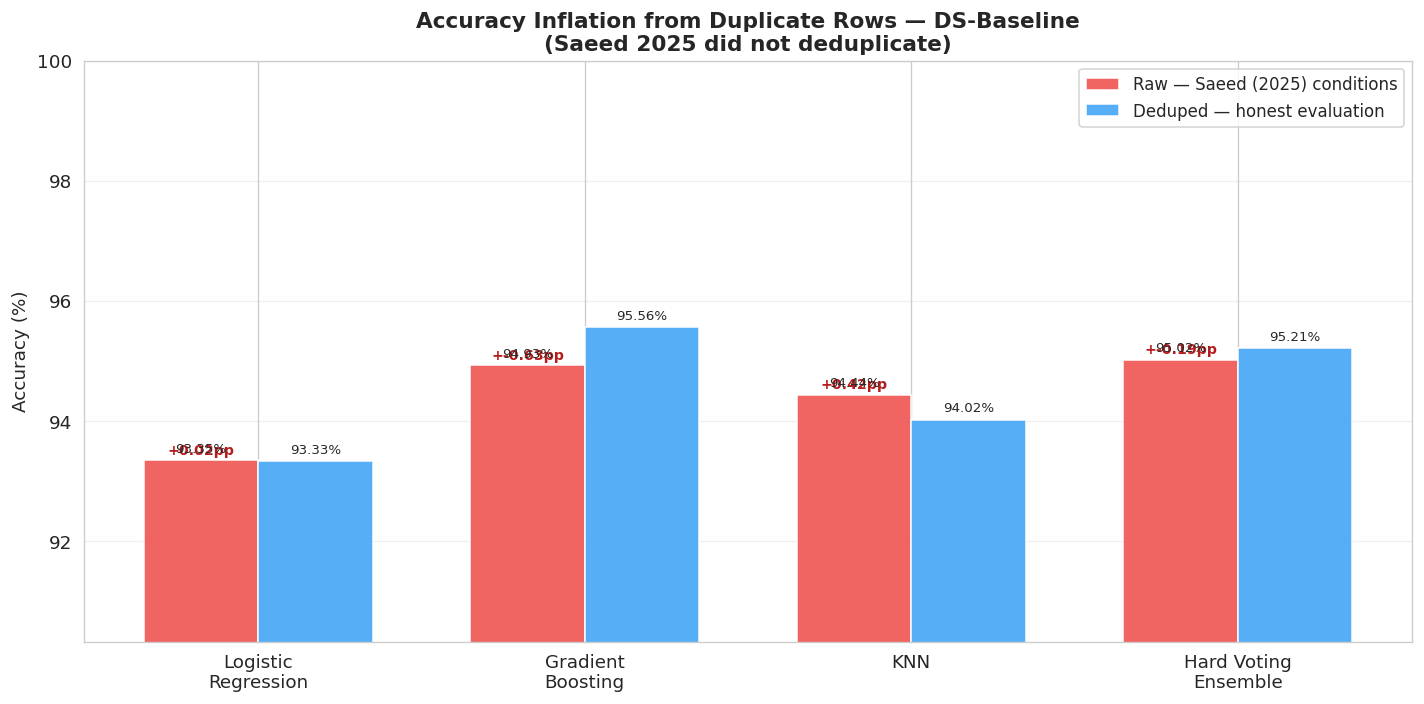

Saved: nb2_inflation.png


In [16]:
# ==========================================
# 9. ACCURACY INFLATION CHART
# ==========================================

raw_acc   = res_raw.set_index('Model')['Accuracy']
dedup_acc = res_dedup.set_index('Model')['Accuracy']

x = np.arange(len(model_order))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, [raw_acc[m] for m in model_order],
            w, label='Raw — Saeed (2025) conditions', color='#EF5350', alpha=0.9)
b2 = ax.bar(x + w/2, [dedup_acc[m] for m in model_order],
            w, label='Deduped — honest evaluation', color='#42A5F5', alpha=0.9)

for i, m in enumerate(model_order):
    inflation = raw_acc[m] - dedup_acc[m]
    ax.annotate(f'+{inflation:.2f}pp',
                xy=(x[i] - w/2, raw_acc[m] + 0.1),
                ha='center', fontsize=8.5, color='#b71c1c', fontweight='bold')

ax.bar_label(b1, fmt='%.2f%%', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.2f%%', fontsize=8, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(['Logistic\nRegression', 'Gradient\nBoosting', 'KNN', 'Hard Voting\nEnsemble'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Inflation from Duplicate Rows — DS-Baseline\n'
             '(Saeed 2025 did not deduplicate)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(min(dedup_acc) - 3, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nb2_inflation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_inflation.png')